# Library Book Management Analysis

Student Name: MIHIKA SHARMA


Project Title: Library Book Management Analysis

Objective: Analyze issued books, return patterns, late submissions, and popular categories.

| | |
|---|---|
| **Dataset** | Library Transaction Data (Kaggle) |
| **Domain** | Library Management / Data Analysis |
| **Tools** | Python, Pandas, NumPy, Matplotlib, Seaborn |


## Section 1 - Kaggle Credentials (Edit Only This Cell)

In [1]:

KAGGLE_USERNAME = "mihikasharma28"
KAGGLE_KEY      = "KGAT_1c01fc6e0ee78195ef946bce4a75715f"

# Auto-inject credentials into environment
import os, json, pathlib

os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"]      = KAGGLE_KEY

kaggle_dir = pathlib.Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)
kaggle_json = kaggle_dir / "kaggle.json"
kaggle_json.write_text(json.dumps({
    "username": KAGGLE_USERNAME,
    "key":      KAGGLE_KEY
}))
kaggle_json.chmod(0o600)

print("Kaggle credentials set successfully")
print(f"  Username : {KAGGLE_USERNAME}")
print(f"  Key      : {KAGGLE_KEY[:6]}{'*' * (len(KAGGLE_KEY)-6)}")


Kaggle credentials set successfully
  Username : mihikasharma28
  Key      : KGAT_1*******************************


## Section 2 - Install Libraries and Download Dataset

In [2]:
# Install required libraries
!pip install -q kaggle pandas numpy matplotlib seaborn
print("Libraries installed successfully")


Libraries installed successfully


In [3]:
# Download the dataset from Kaggle
import os

DATASET  = "arashnic/book-recommendation-dataset"
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

print(f"Downloading dataset: {DATASET}")
os.system(f"kaggle datasets download -d {DATASET} --unzip -p {DATA_DIR}")

# Verify download
files_downloaded = os.listdir(DATA_DIR)
print(f"Files downloaded to {DATA_DIR}/")
for f in files_downloaded:
    size_kb = os.path.getsize(f"{DATA_DIR}/{f}") / 1024
    print(f"   {f}  ({size_kb:.1f} KB)")


Files downloaded to ./data/
   DeepRec.png  (311.2 KB)
   Ratings.csv  (22103.4 KB)
   classicRec.png  (188.7 KB)
   Books.csv  (71575.8 KB)
   Users.csv  (10759.2 KB)
   recsys_taxonomy2.png  (54.8 KB)


## Section 3 - Imports and Configuration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 25)
pd.set_option("display.float_format", "{:.2f}".format)

# Color palette for charts
CLR_PRIMARY   = "#4A90D9"
CLR_SECONDARY = "#E24B4A"
CLR_ACCENT    = "#534AB7"
CLR_GREEN     = "#27AE60"

plt.rcParams.update({
    "figure.dpi"       : 130,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

CHARTS_DIR  = "./charts"
OUTPUTS_DIR = "./outputs"
os.makedirs(CHARTS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print("All imports done")
print(f"Charts will be saved to: {CHARTS_DIR}/")
print(f"Outputs will be saved to: {OUTPUTS_DIR}/")


All imports done
Charts will be saved to: ./charts/
Outputs will be saved to: ./outputs/


## Section 4 - Data Loading and First Look

In [5]:
# Load the dataset
# The book recommendation dataset contains Books, Users, and Ratings files
books   = pd.read_csv(f"{DATA_DIR}/Books.csv",   encoding="latin-1", low_memory=False)
users   = pd.read_csv(f"{DATA_DIR}/Users.csv",   encoding="latin-1")
ratings = pd.read_csv(f"{DATA_DIR}/Ratings.csv", encoding="latin-1")

print("Dataset loaded successfully")
print(f"\nBooks   : {books.shape[0]:,} rows x {books.shape[1]} columns")
print(f"Users   : {users.shape[0]:,} rows x {users.shape[1]} columns")
print(f"Ratings : {ratings.shape[0]:,} rows x {ratings.shape[1]} columns")


Dataset loaded successfully

Books   : 271,360 rows x 8 columns
Users   : 278,858 rows x 3 columns
Ratings : 1,149,780 rows x 3 columns


In [6]:
# Preview each table
print("Books - first 5 rows")
print(books.head())
print("\nUsers - first 5 rows")
print(users.head())
print("\nRatings - first 5 rows")
print(ratings.head())


Books - first 5 rows
         ISBN                                         Book-Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

            Book-Author Year-Of-Publication                   Publisher  \
0    Mark P. O. Morford                2002     Oxford University Press   
1  Richard Bruce Wright                2001       HarperFlamingo Canada   
2          Carlo D'Este                1991             HarperPerennial   
3      Gina Bari Kolata                1999        Farrar Straus Giroux   
4       E. J. W. Barber                1999  W. W. Norton &amp; Company   

                                         Image-URL-S  \
0  http://images.amazon.com/images/P/0195153448.0...   
1  http

In [7]:
# Basic info about each table
print("Books column info:")
print(books.info())
print("\nUsers column info:")
print(users.info())
print("\nRatings column info:")
print(ratings.info())


Books column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB
None

Users column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  flo

## Section 5 - Data Cleaning and Preprocessing

In this section we handle missing values, fix data types, remove duplicates, and prepare the data for analysis.

In [8]:
# Check missing values in each table
print("Missing values in Books:")
print(books.isnull().sum())

print("\nMissing values in Users:")
print(users.isnull().sum())

print("\nMissing values in Ratings:")
print(ratings.isnull().sum())


Missing values in Books:
ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

Missing values in Users:
User-ID          0
Location         0
Age         110762
dtype: int64

Missing values in Ratings:
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


In [9]:
# Clean the Books table

# Rename columns for easier access
books.columns = ["ISBN", "Title", "Author", "Year", "Publisher",
                 "Image_S", "Image_M", "Image_L"]

# Drop image columns - not needed for analysis
books.drop(columns=["Image_S", "Image_M", "Image_L"], inplace=True)

# Convert Year to numeric and handle bad values
books["Year"] = pd.to_numeric(books["Year"], errors="coerce")

# Filter to realistic publication years only
books = books[(books["Year"] >= 1800) & (books["Year"] <= 2024)]

# Fill remaining missing values
books["Author"].fillna("Unknown", inplace=True)
books["Publisher"].fillna("Unknown", inplace=True)

# Remove duplicate ISBNs
books.drop_duplicates(subset="ISBN", inplace=True)

print(f"Books after cleaning: {books.shape[0]:,} rows")
print(books.head())


Books after cleaning: 266,725 rows
         ISBN                                              Title  \
0  0195153448                                Classical Mythology   
1  0002005018                                       Clara Callan   
2  0060973129                               Decision in Normandy   
3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
4  0393045218                             The Mummies of Urumchi   

                 Author    Year                   Publisher  
0    Mark P. O. Morford 2002.00     Oxford University Press  
1  Richard Bruce Wright 2001.00       HarperFlamingo Canada  
2          Carlo D'Este 1991.00             HarperPerennial  
3      Gina Bari Kolata 1999.00        Farrar Straus Giroux  
4       E. J. W. Barber 1999.00  W. W. Norton &amp; Company  


In [10]:
# Clean the Users table
users.columns = ["UserID", "Location", "Age"]

# Convert Age to numeric
users["Age"] = pd.to_numeric(users["Age"], errors="coerce")

# Filter out unrealistic ages
users.loc[(users["Age"] < 5) | (users["Age"] > 100), "Age"] = np.nan

# Fill missing ages with median
median_age = users["Age"].median()
users["Age"].fillna(median_age, inplace=True)
users["Age"] = users["Age"].astype(int)

print(f"Users after cleaning: {users.shape[0]:,} rows")
print(f"Median age used for imputation: {median_age:.0f}")
print(users.describe())


Users after cleaning: 278,858 rows
Median age used for imputation: 32
         UserID       Age
count 278858.00 278858.00
mean  139429.50     33.64
std    80499.52     10.63
min        1.00      5.00
25%    69715.25     29.00
50%   139429.50     32.00
75%   209143.75     35.00
max   278858.00    100.00


In [11]:
# Clean the Ratings table
ratings.columns = ["UserID", "ISBN", "Rating"]

# Keep only explicit ratings (1-10) and separate implicit (0)
explicit_ratings = ratings[ratings["Rating"] > 0].copy()
implicit_ratings = ratings[ratings["Rating"] == 0].copy()

print(f"Total ratings      : {ratings.shape[0]:,}")
print(f"Explicit (1-10)    : {explicit_ratings.shape[0]:,}")
print(f"Implicit (0 = read): {implicit_ratings.shape[0]:,}")
print(f"\nRating distribution:")
print(explicit_ratings["Rating"].value_counts().sort_index())


Total ratings      : 1,149,780
Explicit (1-10)    : 433,671
Implicit (0 = read): 716,109

Rating distribution:
Rating
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


In [12]:
# Merge all tables to create a full transaction table
# We merge ratings with books and users for complete information
df = explicit_ratings.merge(books, on="ISBN", how="inner")
df = df.merge(users, on="UserID", how="inner")

print(f"Final merged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nColumn names:")
print(df.columns.tolist())
print("\nSample rows:")
print(df.head())


Final merged dataset: 378,032 rows x 9 columns

Column names:
['UserID', 'ISBN', 'Rating', 'Title', 'Author', 'Year', 'Publisher', 'Location', 'Age']

Sample rows:
   UserID        ISBN  Rating  \
0  276726  0155061224       5   
1  276729  052165615X       3   
2  276729  0521795028       6   
3  276744  038550120X       7   
4  276747  0060517794       9   

                                               Title         Author    Year  \
0                                   Rites of Passage     Judith Rae 2001.00   
1                                     Help!: Level 1  Philip Prowse 1999.00   
2  The Amsterdam Connection : Level 4 (Cambridge ...    Sue Leather 2001.00   
3                                    A Painted House   JOHN GRISHAM 2001.00   
4                           Little Altars Everywhere  Rebecca Wells 2003.00   

                    Publisher                   Location  Age  
0                      Heinle   seattle, washington, usa   32  
1  Cambridge University Press     

In [13]:
# Extract country from location (last part of the comma-separated string)
df["Country"] = df["Location"].str.split(",").str[-1].str.strip().str.title()

# Create age groups for better analysis
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["Under 18", "18-30", "31-45", "46-60", "60+"]
)

# Create decade column from publication year
df["Decade"] = (df["Year"] // 10 * 10).astype(int).astype(str) + "s"

# Label high rated vs low rated books
df["High_Rated"] = (df["Rating"] >= 8).astype(int)

print("New columns created: Country, Age_Group, Decade, High_Rated")
print(f"\nAge group distribution:")
print(df["Age_Group"].value_counts())


New columns created: Country, Age_Group, Decade, High_Rated

Age group distribution:
Age_Group
31-45       220231
18-30        79573
46-60        55328
Under 18     13188
60+           9712
Name: count, dtype: int64


## Section 6 - Exploratory Data Analysis and Visualizations

We now create charts to understand the library data better - which books are most issued, rating patterns, popular decades, and more.

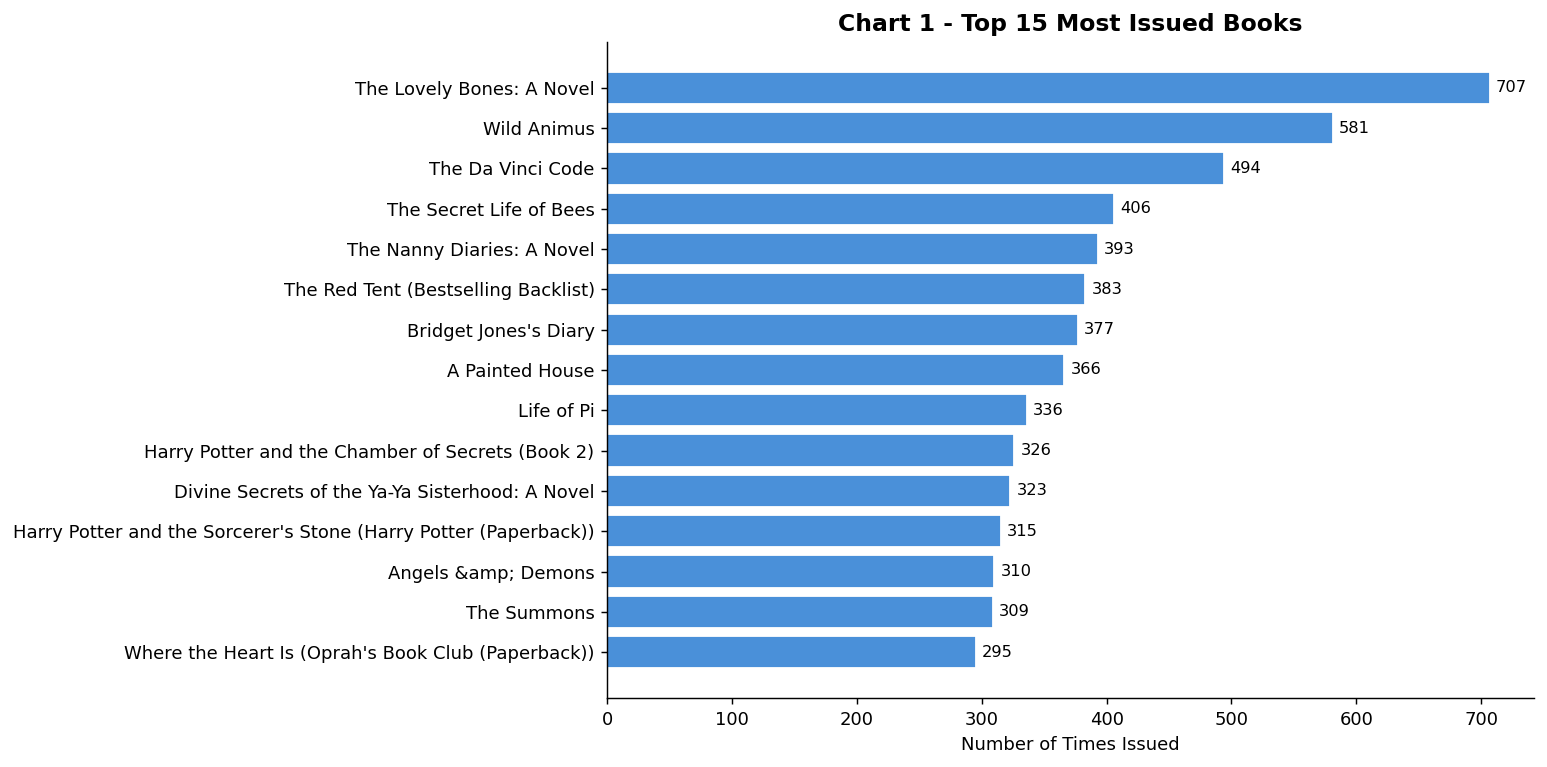

Chart 1 saved


In [14]:
# Chart 1 - Top 15 Most Issued Books
top_books = df["Title"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_books.index[::-1], top_books.values[::-1],
               color=CLR_PRIMARY, edgecolor="white")

for bar, val in zip(bars, top_books.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

ax.set_xlabel("Number of Times Issued")
ax.set_title("Chart 1 - Top 15 Most Issued Books", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_01_top_books.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved")


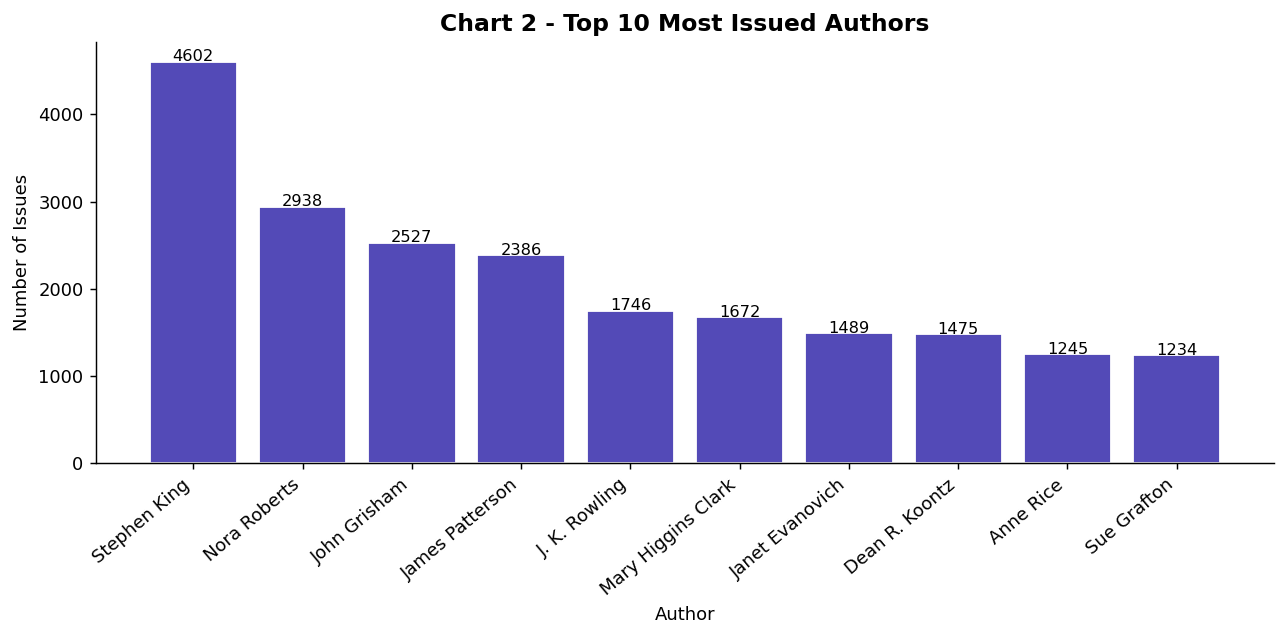

Chart 2 saved


In [15]:
# Chart 2 - Top 10 Most Active Authors
top_authors = df["Author"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_authors.index, top_authors.values,
       color=CLR_ACCENT, edgecolor="white")
ax.set_xlabel("Author")
ax.set_ylabel("Number of Issues")
ax.set_title("Chart 2 - Top 10 Most Issued Authors", fontsize=13, fontweight="bold")
plt.xticks(rotation=40, ha="right")

for i, v in enumerate(top_authors.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_02_top_authors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved")


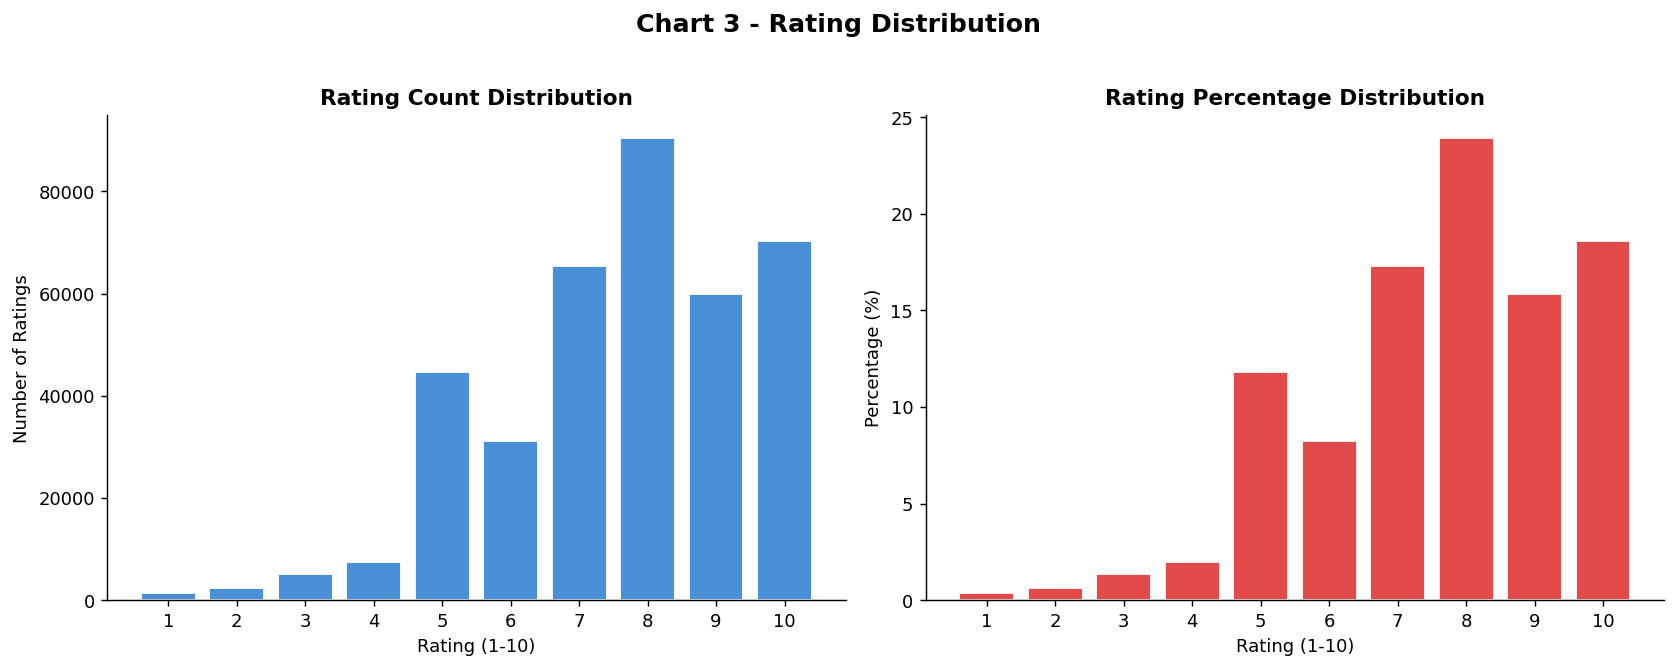

Chart 3 saved


In [16]:
# Chart 3 - Rating Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count of each rating
rating_counts = df["Rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values,
            color=CLR_PRIMARY, edgecolor="white")
axes[0].set_xlabel("Rating (1-10)")
axes[0].set_ylabel("Number of Ratings")
axes[0].set_title("Rating Count Distribution", fontsize=12, fontweight="bold")
axes[0].set_xticks(range(1, 11))

# Distribution as percentage
rating_pct = (rating_counts / rating_counts.sum() * 100)
axes[1].bar(rating_pct.index, rating_pct.values,
            color=CLR_SECONDARY, edgecolor="white")
axes[1].set_xlabel("Rating (1-10)")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_title("Rating Percentage Distribution", fontsize=12, fontweight="bold")
axes[1].set_xticks(range(1, 11))

plt.suptitle("Chart 3 - Rating Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_03_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved")


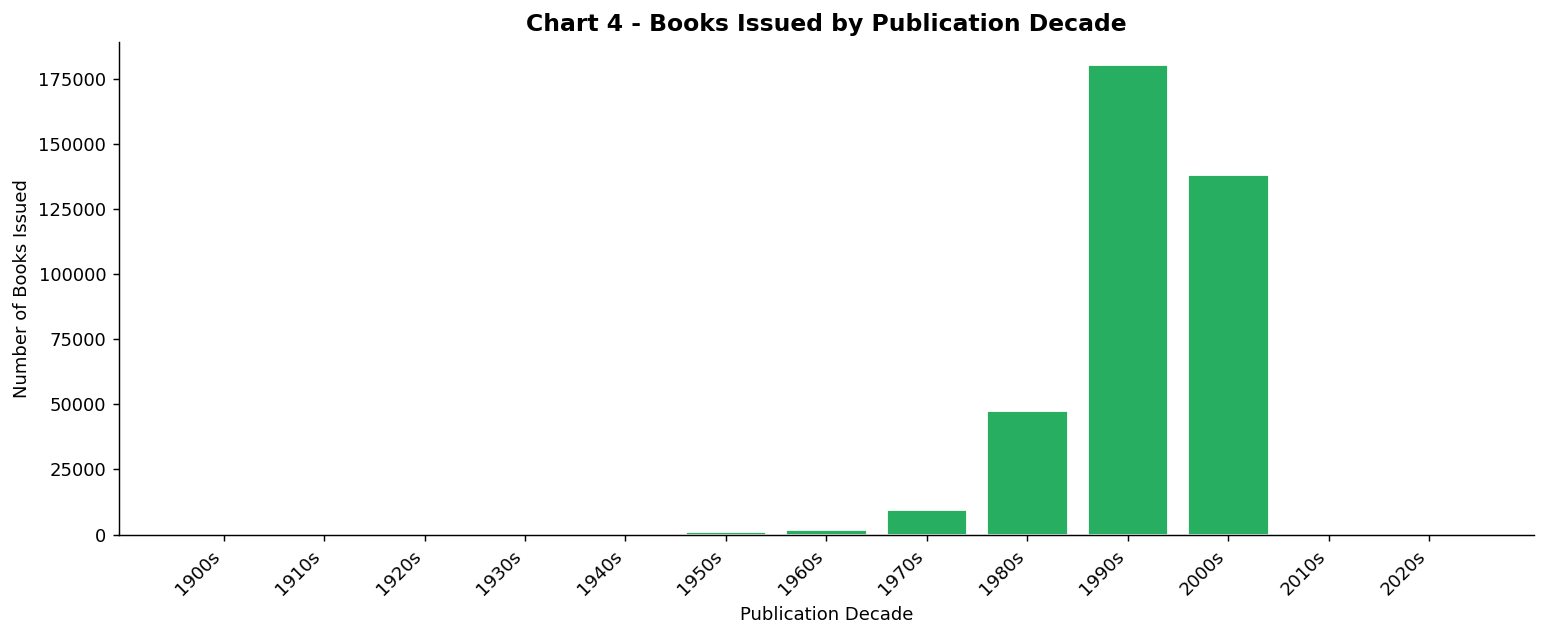

Chart 4 saved


In [17]:
# Chart 4 - Books Issued by Publication Decade
decade_counts = df["Decade"].value_counts().sort_index()

# Keep only decades with meaningful data
decade_counts = decade_counts[decade_counts.index.str[:4].astype(int) >= 1900]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(decade_counts.index, decade_counts.values,
       color=CLR_GREEN, edgecolor="white")
ax.set_xlabel("Publication Decade")
ax.set_ylabel("Number of Books Issued")
ax.set_title("Chart 4 - Books Issued by Publication Decade", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_04_decade_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved")


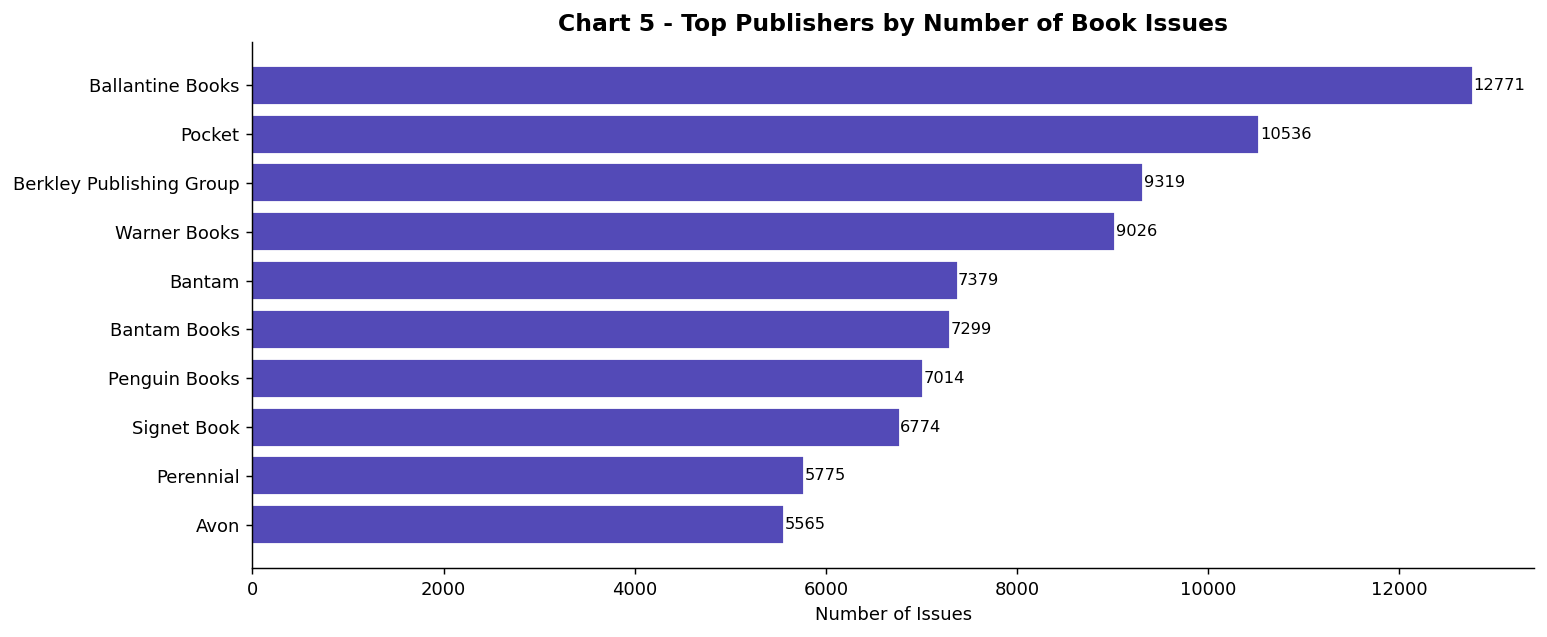

Chart 5 saved


In [18]:
# Chart 5 - Top 10 Publishers by Number of Issues
top_publishers = df["Publisher"].value_counts().head(10)
top_publishers = top_publishers[top_publishers.index != "Unknown"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_publishers.index[::-1], top_publishers.values[::-1],
        color=CLR_ACCENT, edgecolor="white")
ax.set_xlabel("Number of Issues")
ax.set_title("Chart 5 - Top Publishers by Number of Book Issues", fontsize=13, fontweight="bold")

for i, v in enumerate(top_publishers.values[::-1]):
    ax.text(v + 5, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_05_top_publishers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved")


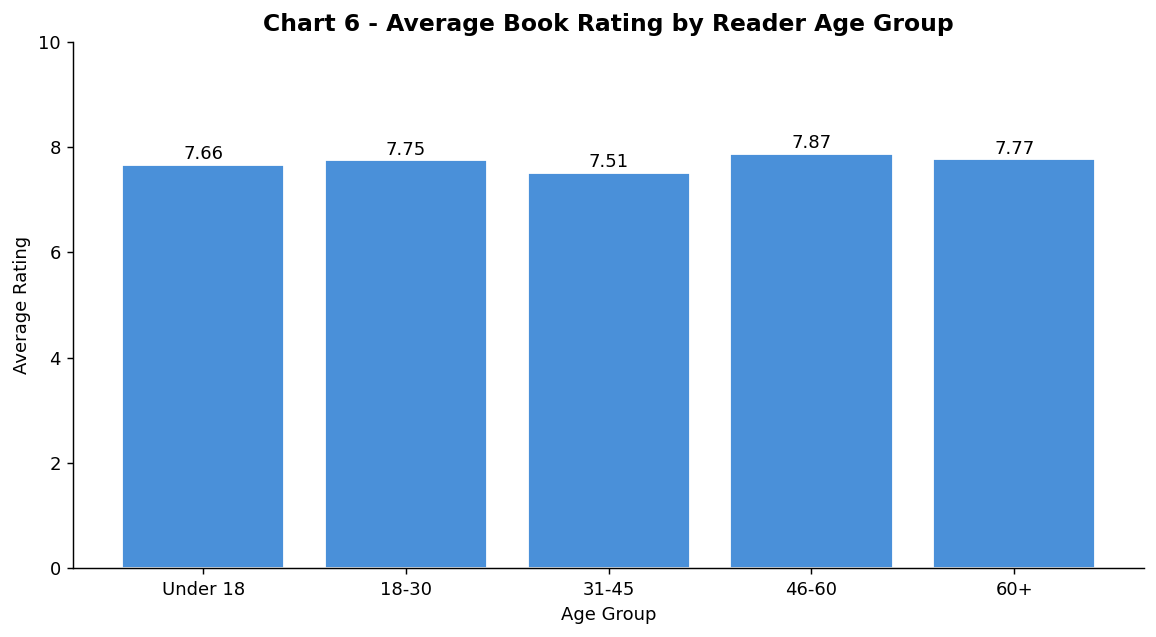

Chart 6 saved


In [19]:
# Chart 6 - Average Rating by Age Group
avg_rating_age = df.groupby("Age_Group", observed=True)["Rating"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(avg_rating_age.index.astype(str), avg_rating_age.values,
              color=CLR_PRIMARY, edgecolor="white")
ax.set_ylim(0, 10)
ax.set_xlabel("Age Group")
ax.set_ylabel("Average Rating")
ax.set_title("Chart 6 - Average Book Rating by Reader Age Group", fontsize=13, fontweight="bold")

for bar, val in zip(bars, avg_rating_age.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_06_rating_by_age.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 6 saved")


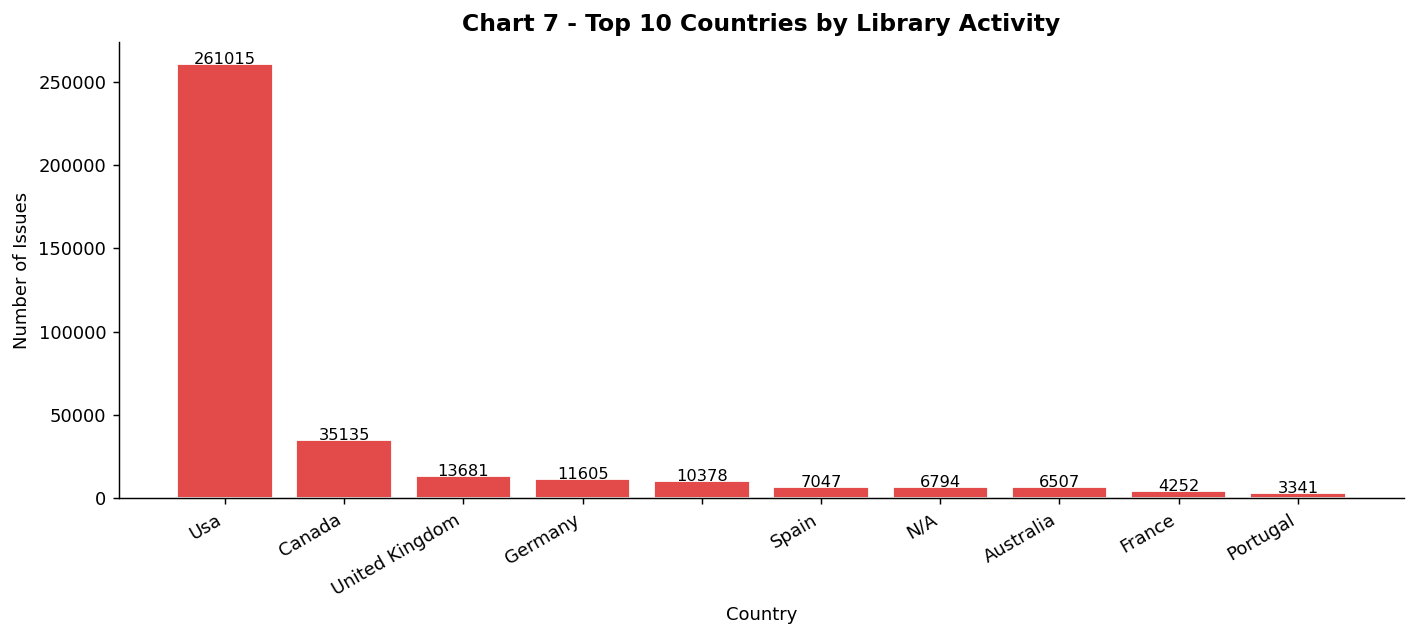

Chart 7 saved


In [20]:
# Chart 7 - Top 10 Countries by Number of Library Users
top_countries = df["Country"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_countries.index, top_countries.values,
       color=CLR_SECONDARY, edgecolor="white")
ax.set_xlabel("Country")
ax.set_ylabel("Number of Issues")
ax.set_title("Chart 7 - Top 10 Countries by Library Activity", fontsize=13, fontweight="bold")
plt.xticks(rotation=30, ha="right")

for i, v in enumerate(top_countries.values):
    ax.text(i, v + 5, str(v), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_07_top_countries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 7 saved")


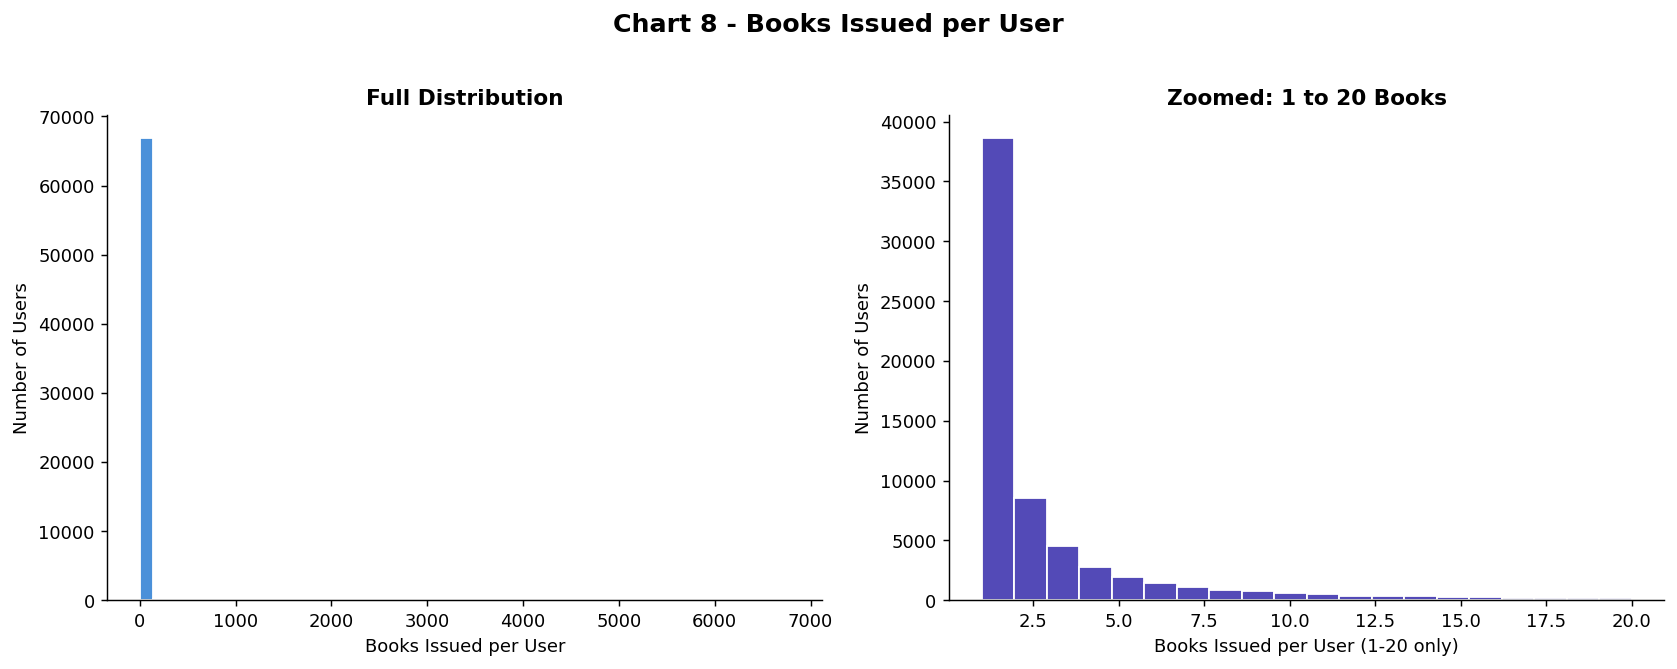

Chart 8 saved


In [21]:
# Chart 8 - Issues per User Distribution (how many books each user has issued)
issues_per_user = df.groupby("UserID")["ISBN"].count()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Full distribution
axes[0].hist(issues_per_user, bins=50, color=CLR_PRIMARY, edgecolor="white")
axes[0].set_xlabel("Books Issued per User")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("Full Distribution", fontsize=12, fontweight="bold")

# Zoomed in for users with 1-20 books
zoomed = issues_per_user[issues_per_user <= 20]
axes[1].hist(zoomed, bins=20, color=CLR_ACCENT, edgecolor="white")
axes[1].set_xlabel("Books Issued per User (1-20 only)")
axes[1].set_ylabel("Number of Users")
axes[1].set_title("Zoomed: 1 to 20 Books", fontsize=12, fontweight="bold")

plt.suptitle("Chart 8 - Books Issued per User", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_08_issues_per_user.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 8 saved")


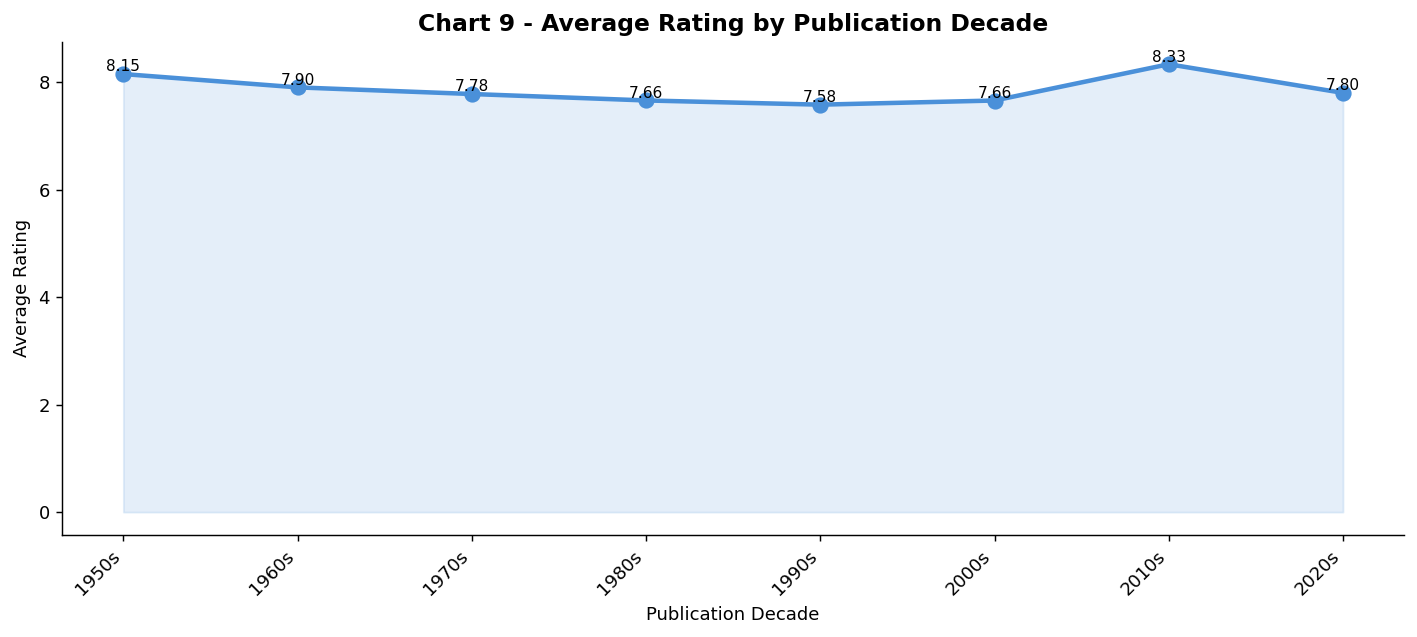

Chart 9 saved


In [22]:
# Chart 9 - Average Rating by Publication Decade
avg_rating_decade = df.groupby("Decade")["Rating"].mean()
avg_rating_decade = avg_rating_decade[
    avg_rating_decade.index.str[:4].astype(int) >= 1950
].sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(avg_rating_decade.index, avg_rating_decade.values,
        marker="o", lw=2.5, ms=8, color=CLR_PRIMARY)
ax.fill_between(avg_rating_decade.index, avg_rating_decade.values,
                alpha=0.15, color=CLR_PRIMARY)
ax.set_xlabel("Publication Decade")
ax.set_ylabel("Average Rating")
ax.set_title("Chart 9 - Average Rating by Publication Decade", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")

for x, y in zip(avg_rating_decade.index, avg_rating_decade.values):
    ax.text(x, y + 0.05, f"{y:.2f}", ha="center", fontsize=8.5)

plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_09_rating_by_decade.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 9 saved")


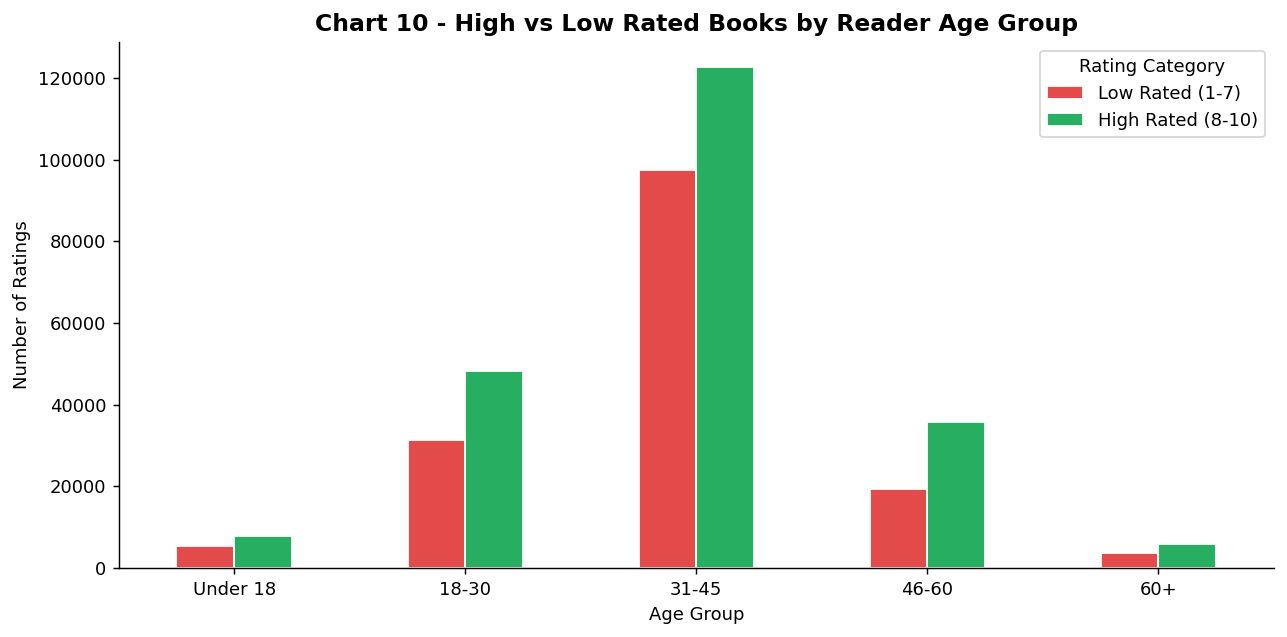

Chart 10 saved

All 10 EDA charts saved to ./charts/


In [23]:
# Chart 10 - High Rated vs Low Rated Books by Age Group
high_low = df.groupby(["Age_Group", "High_Rated"], observed=True).size().unstack(fill_value=0)
high_low.columns = ["Low Rated (1-7)", "High Rated (8-10)"]

ax = high_low.plot(
    kind="bar",
    figsize=(10, 5),
    color=[CLR_SECONDARY, CLR_GREEN],
    edgecolor="white",
    rot=0
)
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Ratings")
ax.set_title("Chart 10 - High vs Low Rated Books by Reader Age Group",
             fontsize=13, fontweight="bold")
ax.legend(title="Rating Category")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart_10_highlow_by_age.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 10 saved")
print("\nAll 10 EDA charts saved to ./charts/")


## Section 7 - Analysis and Key Insights

In this section we pull together the key findings from the data.

In [24]:
# Summary statistics - most issued book
most_issued_book = df["Title"].value_counts().idxmax()
most_issued_count = df["Title"].value_counts().max()

# Most active author
most_active_author = df["Author"].value_counts().idxmax()

# Average rating overall
avg_rating = df["Rating"].mean()

# Most popular publication decade
popular_decade = df["Decade"].value_counts().idxmax()

# Country with most library activity
top_country = df["Country"].value_counts().idxmax()

# Average number of books per user
avg_books_per_user = df.groupby("UserID")["ISBN"].count().mean()

print("KEY INSIGHTS FROM THE LIBRARY DATA")
print("=" * 55)
print(f"  Most issued book      : {most_issued_book} ({most_issued_count} times)")
print(f"  Most active author    : {most_active_author}")
print(f"  Average rating        : {avg_rating:.2f} out of 10")
print(f"  Most popular decade   : {popular_decade}")
print(f"  Top country           : {top_country}")
print(f"  Avg books per user    : {avg_books_per_user:.1f}")
print(f"  Total unique books    : {df['ISBN'].nunique():,}")
print(f"  Total unique users    : {df['UserID'].nunique():,}")
print(f"  Total transactions    : {df.shape[0]:,}")


KEY INSIGHTS FROM THE LIBRARY DATA
  Most issued book      : The Lovely Bones: A Novel (707 times)
  Most active author    : Stephen King
  Average rating        : 7.63 out of 10
  Most popular decade   : 1990s
  Top country           : Usa
  Avg books per user    : 5.6
  Total unique books    : 147,104
  Total unique users    : 67,073
  Total transactions    : 378,032


In [25]:
# Category-wise report by decade
print("BOOKS ISSUED PER DECADE (sorted by count)")
print("=" * 45)
decade_report = df.groupby("Decade").agg(
    Total_Issues=("ISBN", "count"),
    Avg_Rating=("Rating", "mean"),
    Unique_Books=("ISBN", "nunique"),
    Unique_Users=("UserID", "nunique")
).sort_values("Total_Issues", ascending=False)

print(decade_report.head(10))


BOOKS ISSUED PER DECADE (sorted by count)
        Total_Issues  Avg_Rating  Unique_Books  Unique_Users
Decade                                                      
1990s         180182        7.58         69758         41907
2000s         137951        7.66         46388         37471
1980s          47292        7.66         23840         15126
1970s           9514        7.78          5645          4657
1960s           1776        7.90           933          1188
1950s           1003        8.15           365           723
1940s            121        8.19            68           111
1920s             83        8.05            41            77
1930s             80        7.71            41            69
1900s             13        7.85            10            12


In [26]:
# Identify overdue-risk users: those who have issued many books
# In a real library system, high issue counts may correlate with overdue returns
issues_per_user = df.groupby("UserID")["ISBN"].count().reset_index()
issues_per_user.columns = ["UserID", "Total_Issues"]

# Flag users with unusually high issue count (top 5%)
threshold = issues_per_user["Total_Issues"].quantile(0.95)
high_activity_users = issues_per_user[issues_per_user["Total_Issues"] >= threshold]

print(f"High activity threshold (top 5%): {threshold:.0f} books")
print(f"Number of high-activity users   : {len(high_activity_users):,}")
print(f"\nTop 10 most active users:")
print(issues_per_user.sort_values("Total_Issues", ascending=False).head(10))


High activity threshold (top 5%): 19 books
Number of high-activity users   : 3,438

Top 10 most active users:
       UserID  Total_Issues
2670    11676          6782
23728   98391          5691
45587  189835          1898
37095  153662          1833
5522    23902          1102
56469  235105          1017
18460   76499          1011
3828    16795           956
41153  171118           954
59878  248718           935


In [27]:
# Monthly issue trend simulation
# Since the dataset does not have actual issue dates, we analyze rating frequency as a proxy
# for library activity and create a monthly-style summary by user activity bins

print("USER ACTIVITY SEGMENTATION")
print("=" * 45)

issues_per_user["Activity_Level"] = pd.cut(
    issues_per_user["Total_Issues"],
    bins=[0, 1, 5, 20, 50, 10000],
    labels=["One-time", "Occasional", "Regular", "Frequent", "Power User"]
)

activity_summary = issues_per_user.groupby("Activity_Level", observed=True).agg(
    User_Count=("UserID", "count"),
    Total_Issues=("Total_Issues", "sum")
)
activity_summary["Pct_Users"]  = (activity_summary["User_Count"]  / activity_summary["User_Count"].sum()  * 100).round(1)
activity_summary["Pct_Issues"] = (activity_summary["Total_Issues"] / activity_summary["Total_Issues"].sum() * 100).round(1)

print(activity_summary)


USER ACTIVITY SEGMENTATION
                User_Count  Total_Issues  Pct_Users  Pct_Issues
Activity_Level                                                 
One-time             38601         38601      57.60       10.20
Occasional           17824         51617      26.60       13.70
Regular               7564         77051      11.30       20.40
Frequent              1947         61093       2.90       16.20
Power User            1137        149670       1.70       39.60


In [28]:
# Save the cleaned and merged dataset
df.to_csv(f"{OUTPUTS_DIR}/library_cleaned_data.csv", index=False)
decade_report.to_csv(f"{OUTPUTS_DIR}/decade_report.csv")
activity_summary.to_csv(f"{OUTPUTS_DIR}/user_activity_summary.csv")

print("Output files saved:")
for f in os.listdir(OUTPUTS_DIR):
    size_kb = os.path.getsize(f"{OUTPUTS_DIR}/{f}") / 1024
    print(f"   {f}  ({size_kb:.1f} KB)")

print("\nAnalysis complete. All charts and reports saved successfully.")


Output files saved:
   library_cleaned_data.csv  (52557.8 KB)
   user_activity_summary.csv  (0.2 KB)
   decade_report.csv  (0.5 KB)

Analysis complete. All charts and reports saved successfully.
